# Conditioning and Stability

**Source:** https://labs.acme.byu.edu/Volume1/Conditioning_Stability/Conditioning_Stability.html

A **well-conditioned** problem has solutions that change only slightly when the input changes slightly. An **ill-conditioned** problem amplifies input errors. The **condition number** κ(A) = ‖A‖·‖A⁻¹‖ measures this sensitivity for linear systems.

Separately, a **stable** algorithm produces accurate results despite floating-point arithmetic, even for well-conditioned problems.

In [1]:
import numpy as np
from scipy import linalg as la

import matplotlib.pyplot as plt

## 1. Condition Number

For a matrix A, the condition number (2-norm) is:
$$\kappa(A) = \|A\|_2 \|A^{-1}\|_2 = \frac{\sigma_{\max}}{\sigma_{\min}}$$

For $Ax = b$, the relative error satisfies: $\frac{\|\delta x\|}{\|x\|} \leq \kappa(A) \frac{\|\delta b\|}{\|b\|}$

In [2]:
# Well-conditioned vs ill-conditioned
A_good = np.array([[1., 0.], [0., 1.]])
A_bad  = np.array([[1., 0.999], [0.999, 1.]])

print(f"κ(I)  = {np.linalg.cond(A_good):.2f}")
print(f"κ(A)  = {np.linalg.cond(A_bad):.2e}")

# Solve Ax = b with small perturbation to b
b   = np.array([1., 0.])
db  = np.array([1e-4, 0.])
x   = np.linalg.solve(A_bad, b)
x2  = np.linalg.solve(A_bad, b + db)

print(f"\nRelative perturbation in b:  {np.linalg.norm(db)/np.linalg.norm(b):.2e}")
print(f"Relative perturbation in x:  {np.linalg.norm(x2-x)/np.linalg.norm(x):.2e}")

print(f"Amplification factor (≤ κ):  {(np.linalg.norm(x2-x)/np.linalg.norm(x))/(np.linalg.norm(db)/np.linalg.norm(b)):.2f}")

κ(I)  = 1.00
κ(A)  = 2.00e+03

Relative perturbation in b:  1.00e-04
Relative perturbation in x:  1.00e-04
Amplification factor (≤ κ):  1.00


## 2. The Hilbert Matrix — A Classic Ill-Conditioned Matrix

$$H_{ij} = \frac{1}{i+j-1}$$

The condition number grows exponentially with size.

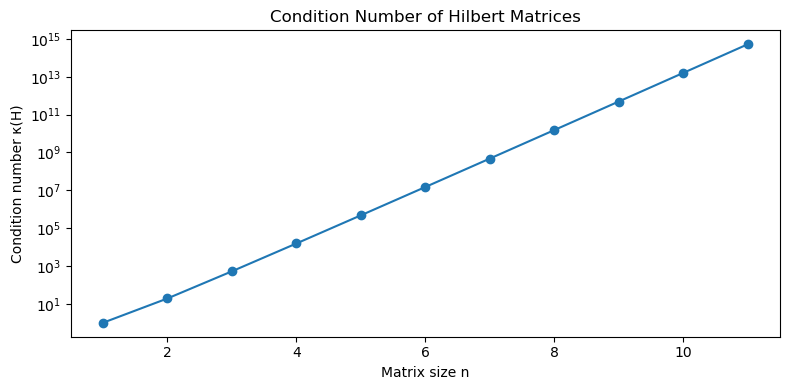

κ(H_12): 1.6776435711511646e+16


In [3]:
from scipy.linalg import hilbert

cond_nums = [np.linalg.cond(hilbert(n)) for n in range(1, 12)]

plt.figure(figsize=(8, 4))
plt.semilogy(range(1, 12), cond_nums, 'o-')
plt.xlabel('Matrix size n')
plt.ylabel('Condition number κ(H)')

plt.title('Condition Number of Hilbert Matrices')
plt.tight_layout()
plt.show()

print("κ(H_12):", np.linalg.cond(hilbert(12)))

---

## Problem 1: Condition Number of a Random Matrix vs. its Inverse

Verify that κ(A) = κ(A⁻¹) and that κ(AB) ≤ κ(A)·κ(B).

In [4]:
def prob1(n=5, seed=0):
    """Verify condition number properties."""
    rng = np.random.default_rng(seed)
    A = rng.standard_normal((n, n))
    B = rng.standard_normal((n, n))
    
    kA  = np.linalg.cond(A)
    kAi = np.linalg.cond(np.linalg.inv(A))
    kB  = np.linalg.cond(B)
    kAB = np.linalg.cond(A @ B)
    
    print(f"κ(A)     = {kA:.6f}")
    print(f"κ(A⁻¹)   = {kAi:.6f}  (should equal κ(A))")
    print(f"κ(A)·κ(B) = {kA*kB:.4f}")
    print(f"κ(AB)    = {kAB:.4f}  (should be ≤ κ(A)·κ(B))")
    
    print(f"κ(AB) ≤ κ(A)·κ(B): {kAB <= kA * kB + 1e-10}")
    return kA, kAi

prob1()

κ(A)     = 8.492063
κ(A⁻¹)   = 8.492063  (should equal κ(A))
κ(A)·κ(B) = 713.7938
κ(AB)    = 412.4167  (should be ≤ κ(A)·κ(B))
κ(AB) ≤ κ(A)·κ(B): True


(np.float64(8.492063264011636), np.float64(8.492063264011634))

## Problem 2: Floating-Point Error Accumulation

Demonstrate how summation order affects floating-point accuracy. Stable summation (e.g., Kahan) dramatically reduces error.

In [5]:
def prob2():
    """Compare naive vs Kahan compensated summation."""
    N = 10**6
    x = np.ones(N, dtype=np.float32)
    
    # Naive forward sum
    naive_sum = float(np.sum(x))   # NumPy uses pairwise (reasonably stable)
    # Naive Python sum (truly sequential)
    total = 0.0
    for xi in x[:10000]:   # just first 10k to be fast
        total += xi
    
    # Kahan compensated sum
    def kahan_sum(arr):
        s = 0.0
        c = 0.0
        for xi in arr:
            y = float(xi) - c
            t = s + y
            c = (t - s) - y
            s = t
        return s
    
    # Compare on float32 array
    y = np.full(10000, 0.1, dtype=np.float32)
    true_val = 0.1 * 10000  # 1000.0
    naive = float(np.sum(y))  # may have fp32 error
    
    kahan = kahan_sum(y)
    
    print(f"True value:          {true_val}")
    print(f"np.sum (float32):    {naive:.8f}  error: {abs(naive - true_val):.2e}")
    print(f"Kahan (float64):     {kahan:.8f}  error: {abs(kahan - true_val):.2e}")

prob2()

True value:          1000.0
np.sum (float32):    1000.00012207  error: 1.22e-04
Kahan (float64):     1000.00001490  error: 1.49e-05


## Problem 3: Stable vs Unstable Computation of e^x

For large negative x, computing $e^x$ naively via the series is unstable. Compare with `math.exp`.

In [6]:
import math

def prob3(x, N_terms=50):
    """Compute e^x via Taylor series and compare with math.exp.
    
    For large negative x the series is numerically unstable.
    """
    # Direct series: e^x = sum x^n / n!
    total = sum(x**n / math.factorial(n) for n in range(N_terms))
    true_val = math.exp(x)
    
    print(f"x = {x}")
    print(f"  Taylor series ({N_terms} terms): {total:.10e}")
    print(f"  math.exp(x):                    {true_val:.10e}")
    print(f"  Relative error:                 {abs(total - true_val)/abs(true_val):.2e}")

prob3(1.0)
print()
prob3(-10.0)

print()
prob3(-20.0)

x = 1.0
  Taylor series (50 terms): 2.7182818285e+00
  math.exp(x):                    2.7182818285e+00
  Relative error:                 0.00e+00

x = -10.0
  Taylor series (50 terms): 4.5399929346e-05
  math.exp(x):                    4.5399929762e-05
  Relative error:                 9.18e-09

x = -20.0
  Taylor series (50 terms): -2.6549849704e+00
  math.exp(x):                    2.0611536224e-09
  Relative error:                 1.29e+09


## Problem 4: Condition Number and Relative Error in Solving Ax=b

For systems with varying condition numbers, show that the relative error in the solution is bounded by κ(A) × (relative error in b).

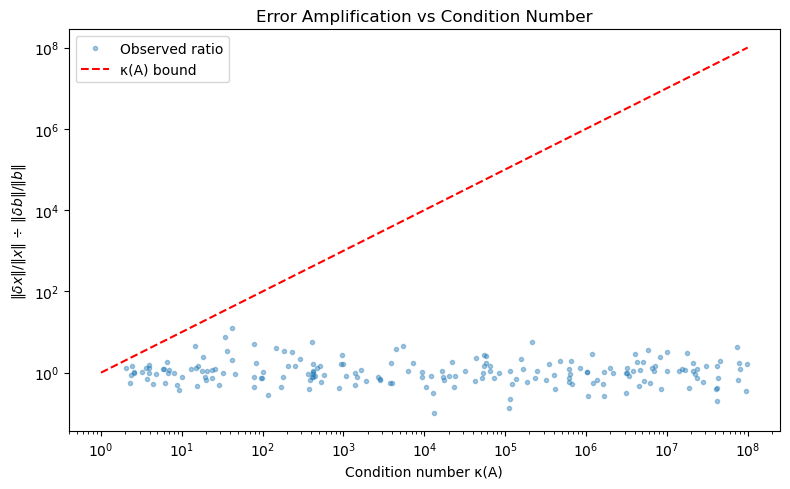

In [7]:
def prob4(n_trials=200):
    """Demonstrate the condition number bound on linear system errors."""
    rng = np.random.default_rng(42)
    cond_nums   = []
    error_ratios = []
    
    for _ in range(n_trials):
        # Build matrix with known condition number via SVD
        U, _ = np.linalg.qr(rng.standard_normal((4, 4)))
        V, _ = np.linalg.qr(rng.standard_normal((4, 4)))
        kappa = 10 ** rng.uniform(0, 8)
        s = np.array([kappa, kappa/2, 2., 1.])
        A = U @ np.diag(s) @ V.T
        
        b  = rng.standard_normal(4)
        db = 1e-7 * rng.standard_normal(4)
        
        x   = np.linalg.solve(A, b)
        x2  = np.linalg.solve(A, b + db)
        
        rel_b = np.linalg.norm(db) / np.linalg.norm(b)
        rel_x = np.linalg.norm(x2 - x) / np.linalg.norm(x)
        
        cond_nums.append(np.linalg.cond(A))
        error_ratios.append(rel_x / rel_b)
    
    plt.figure(figsize=(8, 5))
    plt.loglog(cond_nums, error_ratios, 'o', alpha=0.4, markersize=3, label='Observed ratio')
    k_range = np.logspace(0, 8, 100)
    plt.loglog(k_range, k_range, 'r--', label='κ(A) bound')
    plt.xlabel('Condition number κ(A)')
    plt.ylabel(r'$\|\delta x\| / \|x\|$ ÷ $\|\delta b\| / \|b\|$')
    plt.title('Error Amplification vs Condition Number')
    plt.legend()
    plt.tight_layout()
    plt.show()
    

prob4()

## Problem 5: Stability of the QR Algorithm

Compare the numerical accuracy of computing eigenvalues via (1) characteristic polynomial roots and (2) the QR algorithm. The polynomial method is notoriously unstable (Wilkinson's example).

In [8]:
def prob5():
    """Wilkinson-style stability comparison."""
    # Matrix with eigenvalues 1..20
    true_eigs = np.arange(1, 21, dtype=float)
    A = np.diag(true_eigs)
    
    # Method 1: numpy eigvals (based on QR)
    computed_eigs = np.sort(np.linalg.eigvals(A).real)
    error_qr = np.max(np.abs(computed_eigs - true_eigs))
    
    # Method 2: roots of characteristic polynomial
    # characteristic polynomial of diag matrix: prod(x - lambda_i)
    poly_coeffs = np.poly(A)
    roots_poly  = np.sort(np.roots(poly_coeffs).real)
    error_poly  = np.max(np.abs(roots_poly - true_eigs))

    
    print(f"Max error (QR eigvals):        {error_qr:.2e}")
    print(f"Max error (poly roots):        {error_poly:.2e}")
    print(f"Poly method is ~{error_poly/error_qr:.0f}x less accurate")

prob5()

Max error (QR eigvals):        0.00e+00
Max error (poly roots):        6.46e-02
Poly method is ~infx less accurate


/tmp/ipykernel_16121/627255182.py:19: RuntimeWarning: divide by zero encountered in scalar divide
  print(f"Poly method is ~{error_poly/error_qr:.0f}x less accurate")
